# Orbit Examples

This notebook demonstrates detailed orbit examples from the galpy documentation,
including the LMC orbit with dynamical friction and the barycentric acceleration
due to the LMC.

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## LMC orbit with dynamical friction

The Large Magellanic Cloud (LMC) is a massive satellite of the Milky Way, so its
orbit is significantly affected by dynamical friction -- a frictional force of
gravitational origin that occurs when a massive object travels through a sea of
low-mass objects (halo stars and dark matter). We investigate the LMC's past and
future orbit using `ChandrasekharDynamicalFrictionForce`.

In [2]:
import numpy
import copy
from astropy import units
from matplotlib import pyplot as plt
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014, ChandrasekharDynamicalFrictionForce
from galpy.util import conversion

Load the current phase-space coordinates for the LMC using `Orbit.from_name`.
Because the LMC is unbound in the default `MWPotential2014`, we increase the
halo mass by 50% (corresponding to a Milky Way halo mass of approximately
1.2 x 10^12 Msun). We use `copy.deepcopy` to avoid modifying the global potential.

In [3]:
o = Orbit.from_name("LMC")

# Make a deep copy to avoid modifying the global MWPotential2014
mwp = copy.deepcopy(MWPotential2014)
mwp[2] *= 1.5  # increase halo mass by 50%

### Orbit without dynamical friction

First, integrate the LMC orbit backward for 10 Gyr without dynamical friction:

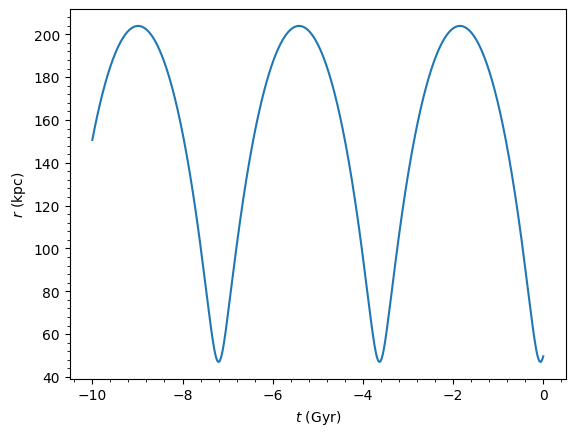

In [4]:
ts = numpy.linspace(0.0, -10.0, 1001) * units.Gyr
o.integrate(ts, mwp)
o.plot(d1="t", d2="r");

The LMC is bound with an apocenter just over 200 kpc.

### Adding dynamical friction (M = 5 x 10^10 Msun)

Now add dynamical friction assuming an LMC mass of 5 x 10^10 Msun:

In [5]:
cdf = ChandrasekharDynamicalFrictionForce(
    GMs=5e10 * units.Msun, rhm=5.0 * units.kpc, dens=mwp
)

# Make a copy of the orbit for the dynamical friction integration
odf = o()
odf.integrate(ts, mwp + cdf)

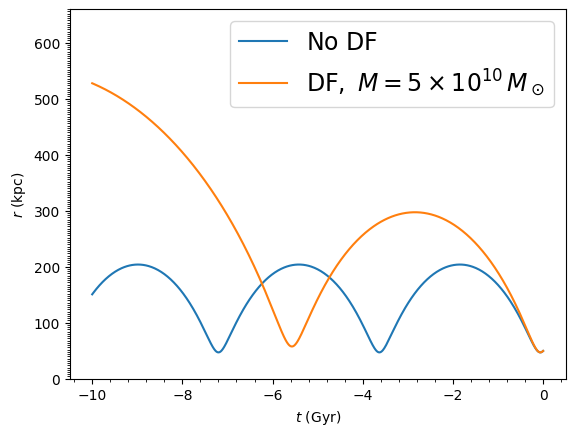

In [6]:
o.plot(d1="t", d2="r", label=r"$\mathrm{No\ DF}$")
odf.plot(
    d1="t", d2="r", overplot=True, label=r"$\mathrm{DF},\ M=5\times10^{10}\,M_\odot$"
)
plt.ylim(0.0, 660.0)
plt.legend(fontsize=17.0);

Dynamical friction removes energy from the LMC's orbit, so the past apocenter
is now around 500 kpc rather than 200 kpc, and the orbital period is much longer.

### A more massive LMC (M = 10^11 Msun)

Recent observations suggest the LMC may be even more massive (> 10^11 Msun).
We can change the mass in the existing `ChandrasekharDynamicalFrictionForce`
object without re-solving the Jeans equation:

In [7]:
cdf.GMs = 1e11 * units.Msun

odf2 = o()
odf2.integrate(ts, mwp + cdf)

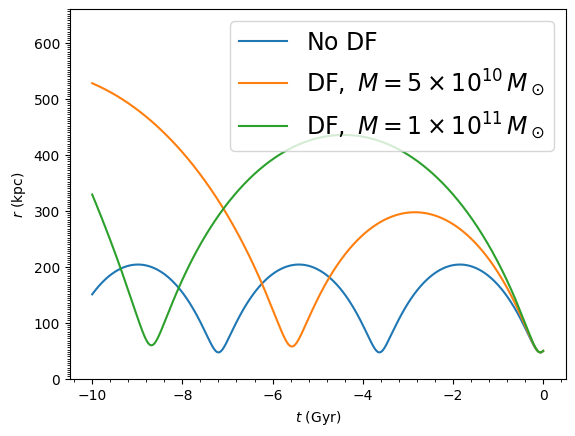

In [8]:
o.plot(d1="t", d2="r", label=r"$\mathrm{No\ DF}$")
odf.plot(
    d1="t", d2="r", overplot=True, label=r"$\mathrm{DF},\ M=5\times10^{10}\,M_\odot$"
)
odf2.plot(
    d1="t", d2="r", overplot=True, label=r"$\mathrm{DF},\ M=1\times10^{11}\,M_\odot$"
)
plt.ylim(0.0, 660.0)
plt.legend(fontsize=17.0);

With a mass of 10^11 Msun, the LMC barely completes a full orbit over 10 Gyr!

### Future orbit: merging timescale

Let's see what happens in the future with the massive LMC. We flip the sign of
the integration times (limiting to 9 Gyr to avoid numerical issues at very
small radii):

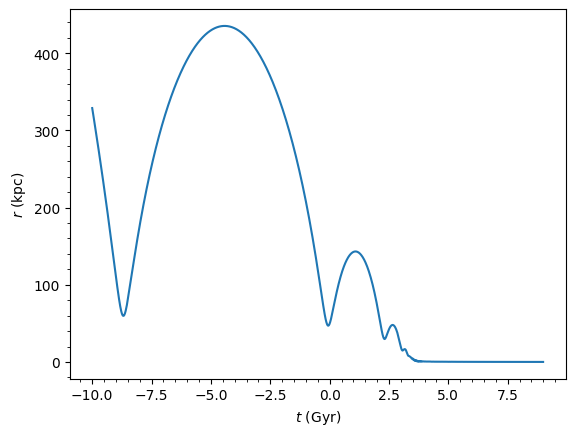

In [9]:
odf2.integrate(-ts[-ts < 9 * units.Gyr], mwp + cdf)
odf2.plot(d1="t", d2="r");

The LMC merges with the Milky Way in about 4 Gyr after a few more pericenter
passages. Mass loss (not included here) would somewhat increase the merging
timescale, but the merger is inevitable.

**Warning**

When using dynamical friction, if the radius gets very small the
integration can become erroneous, leading to unphysical kicks. Always inspect
the full orbit to check whether a merger has happened.

## Barycentric acceleration due to the LMC

The LMC is so massive that it pulls the center of the Milky Way towards it,
meaning the Galactocentric reference frame is not truly inertial. We can
account for this using `NonInertialFrameForce`.

Our approach: (1) compute the LMC orbit assuming the MW is at rest, (2) compute
the acceleration at the origin due to the LMC along that orbit, (3) use
`NonInertialFrameForce` with that acceleration.

In [10]:
from galpy.potential import (
    HernquistPotential,
    MovingObjectPotential,
    NonInertialFrameForce,
    evaluateRforces,
    evaluatephitorques,
    evaluatezforces,
)

We already computed the LMC orbit with dynamical friction above. Now we
re-compute it over 10 Gyr backward using the massive LMC setup:

In [11]:
# Re-integrate LMC orbit backward with the heavy LMC
o_lmc = Orbit.from_name("LMC")
ts_back = numpy.linspace(0.0, -10.0, 1001) * units.Gyr
o_lmc.integrate(ts_back, mwp + cdf)

Define the LMC as a `HernquistPotential` and create a `MovingObjectPotential`
that follows its orbit:

In [12]:
# Hernquist potential for LMC: rhm = (1+sqrt(2)) * a
lmcpot = HernquistPotential(
    amp=2e11 * units.Msun, a=5.0 * units.kpc / (1.0 + numpy.sqrt(2.0))
)
moving_lmcpot = MovingObjectPotential(o_lmc, pot=lmcpot)

Compute the acceleration of the Galactic center due to the LMC. We evaluate
forces at a small offset from the origin (to avoid numerical issues in
cylindrical coordinates) and build interpolated versions for speed:

In [13]:
loc_origin = 1e-4  # small offset in R
ax = lambda t: evaluateRforces(
    moving_lmcpot, loc_origin, 0.0, phi=0.0, t=t, use_physical=False
)
ay = lambda t: (
    evaluatephitorques(moving_lmcpot, loc_origin, 0.0, phi=0.0, t=t, use_physical=False)
    / loc_origin
)
az = lambda t: evaluatezforces(
    moving_lmcpot, loc_origin, 0.0, phi=0.0, t=t, use_physical=False
)

# Build interpolated versions for speed
if o_lmc.time(use_physical=False)[0] > o_lmc.time(use_physical=False)[1]:
    t_intunits = o_lmc.time(use_physical=False)[::-1]
else:
    t_intunits = o_lmc.time(use_physical=False)

ax4int = numpy.array([ax(t) for t in t_intunits])
ax_int = lambda t: numpy.interp(t, t_intunits, ax4int)
ay4int = numpy.array([ay(t) for t in t_intunits])
ay_int = lambda t: numpy.interp(t, t_intunits, ay4int)
az4int = numpy.array([az(t) for t in t_intunits])
az_int = lambda t: numpy.interp(t, t_intunits, az4int)

Set up the `NonInertialFrameForce` with the origin's acceleration:

In [14]:
nip = NonInertialFrameForce(a0=[ax_int, ay_int, az_int])

### Effect on the Sun's orbit

Compare the Sun's past orbit with and without the barycentric correction.
When including the non-inertial correction, we must also include the LMC's
gravitational potential (`moving_lmcpot`) to keep the model self-consistent:

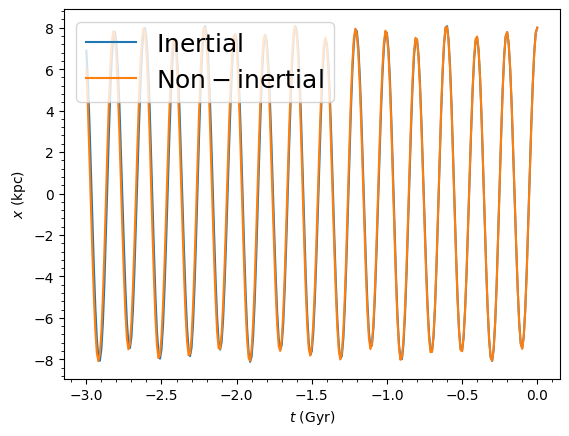

In [15]:
sunts = numpy.linspace(0.0, -3.0, 301) * units.Gyr

osun_inertial = Orbit()
osun_inertial.integrate(sunts, mwp)
osun_inertial.plotx(label=r"$\mathrm{Inertial}$")

osun_noninertial = Orbit()
osun_noninertial.integrate(sunts, mwp + nip + moving_lmcpot)
osun_noninertial.plotx(overplot=True, label=r"$\mathrm{Non-inertial}$")
plt.legend(fontsize=18.0, loc="upper left", framealpha=0.8);

There is essentially no difference for the Sun, because its orbit is close to
the Galactic center where the LMC's pull on the origin is largely cancelled
by the direct attraction to the LMC.

### Effect on a distant dwarf galaxy (Fornax)

For objects orbiting far in the halo, the effect is more significant:

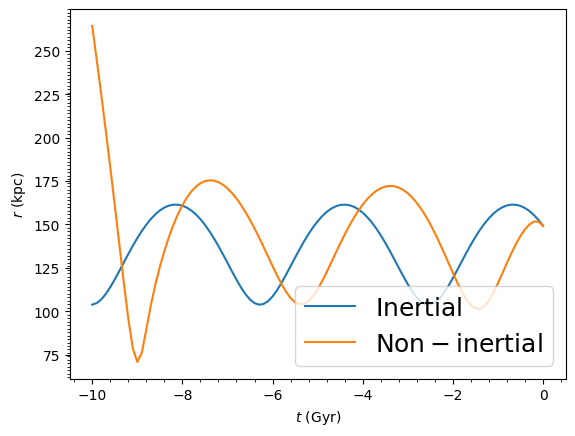

In [16]:
fornaxts = numpy.linspace(0.0, -10.0, 101) * units.Gyr

ofornax_inertial = Orbit.from_name("Fornax")
ofornax_inertial.integrate(fornaxts, mwp)
ofornax_inertial.plotr(label=r"$\mathrm{Inertial}$")

ofornax_noninertial = Orbit.from_name("Fornax")
ofornax_noninertial.integrate(fornaxts, mwp + nip + moving_lmcpot)
ofornax_noninertial.plotr(overplot=True, label=r"$\mathrm{Non-inertial}$")
plt.autoscale()
plt.legend(fontsize=18.0, loc="lower right", framealpha=0.8);

For Fornax, the past orbit differs significantly when the barycentric
acceleration is taken into account. The abrupt change around -8 Gyr is caused
by the LMC's previous pericenter passage in our model.

### Checking the acceleration: displacement, velocity, and force

We can verify the acceleration is realistic by integrating it to get the
displacement and velocity of the MW center, and comparing to the results of
Vasiliev et al. (2021):

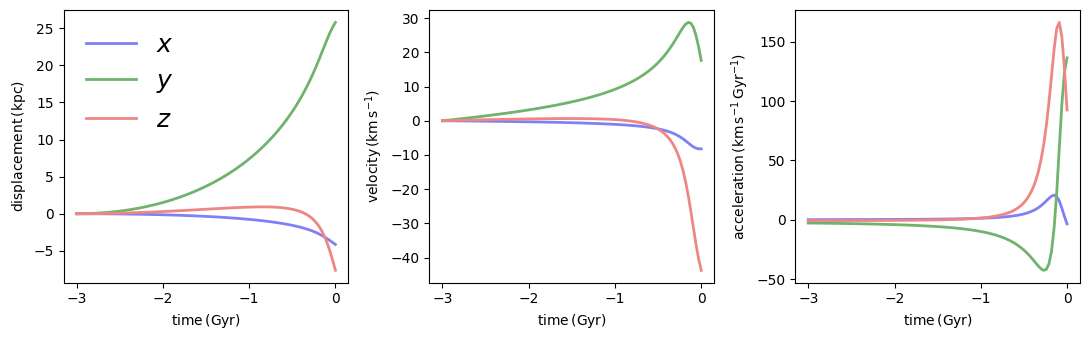

In [17]:
from scipy import integrate

vo, ro = 220.0, 8.0
int_ts_phys = numpy.linspace(-3.0, 0.0, 101)
int_ts = int_ts_phys / conversion.time_in_Gyr(vo, ro)

ax4plot = ax_int(int_ts)
ay4plot = ay_int(int_ts)
az4plot = az_int(int_ts)

vx4plot = integrate.cumulative_trapezoid(ax4plot, x=int_ts, initial=0.0)
vy4plot = integrate.cumulative_trapezoid(ay4plot, x=int_ts, initial=0.0)
vz4plot = integrate.cumulative_trapezoid(az4plot, x=int_ts, initial=0.0)

xx4plot = integrate.cumulative_trapezoid(vx4plot, x=int_ts, initial=0.0)
xy4plot = integrate.cumulative_trapezoid(vy4plot, x=int_ts, initial=0.0)
xz4plot = integrate.cumulative_trapezoid(vz4plot, x=int_ts, initial=0.0)

plt.figure(figsize=(11, 3.5))

plt.subplot(1, 3, 1)
plt.plot(
    int_ts_phys, xx4plot * ro, color=(0.5, 0.5, 247.0 / 256.0), lw=2.0, label=r"$x$"
)
plt.plot(
    int_ts_phys,
    xy4plot * ro,
    color=(111.0 / 256, 180.0 / 256, 109.0 / 256),
    lw=2.0,
    label=r"$y$",
)
plt.plot(
    int_ts_phys,
    xz4plot * ro,
    color=(239.0 / 256, 135.0 / 256, 132.0 / 256),
    lw=2.0,
    label=r"$z$",
)
plt.xlabel(r"$\mathrm{time}\,(\mathrm{Gyr})$")
plt.ylabel(r"$\mathrm{displacement}\,(\mathrm{kpc})$")
plt.legend(frameon=False, fontsize=18.0)

plt.subplot(1, 3, 2)
plt.plot(int_ts_phys, vx4plot * vo, color=(0.5, 0.5, 247.0 / 256.0), lw=2.0)
plt.plot(
    int_ts_phys, vy4plot * vo, color=(111.0 / 256, 180.0 / 256, 109.0 / 256), lw=2.0
)
plt.plot(
    int_ts_phys, vz4plot * vo, color=(239.0 / 256, 135.0 / 256, 132.0 / 256), lw=2.0
)
plt.xlabel(r"$\mathrm{time}\,(\mathrm{Gyr})$")
plt.ylabel(r"$\mathrm{velocity}\,(\mathrm{km\,s}^{-1})$")

plt.subplot(1, 3, 3)
plt.plot(
    int_ts_phys,
    -ax4plot * conversion.force_in_kmsMyr(vo, ro) * 1000.0,
    color=(0.5, 0.5, 247.0 / 256.0),
    lw=2.0,
)
plt.plot(
    int_ts_phys,
    -ay4plot * conversion.force_in_kmsMyr(vo, ro) * 1000.0,
    color=(111.0 / 256, 180.0 / 256, 109.0 / 256),
    lw=2.0,
)
plt.plot(
    int_ts_phys,
    -az4plot * conversion.force_in_kmsMyr(vo, ro) * 1000.0,
    color=(239.0 / 256, 135.0 / 256, 132.0 / 256),
    lw=2.0,
)
plt.xlabel(r"$\mathrm{time}\,(\mathrm{Gyr})$")
plt.ylabel(r"$\mathrm{acceleration}\,(\mathrm{km\,s}^{-1}\,\mathrm{Gyr}^{-1})$")

plt.tight_layout();

The main trends and magnitudes are consistent with Figure 10 of Vasiliev et al.
(2021), confirming that our simple approximation gives a reasonable estimate of
the Galactocentric reference frame's acceleration.